In [ ]:
!pip install -q "nvflare>=2.5" torch torchvision matplotlib

import os, glob, shutil, sys
import numpy as np
import torch, torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

NUM_SITES    = 3
NUM_ROUNDS   = 5
LOCAL_EPOCHS = 1
ALPHA        = 0.3
MAX_SAMPLES  = 4000
BATCH_SIZE   = 64
LR           = 0.01
DATA_ROOT    = "/tmp/nvflare/data"
RESULTS_DIR  = "/tmp/nvflare/results"
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True,  download=True)
torchvision.datasets.CIFAR10(root=DATA_ROOT, train=False, download=True)

In [ ]:
CLIENT_SCRIPT = r'''
import argparse, os, csv
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

import nvflare.client as flare


class Net(nn.Module):
    """Small CNN for CIFAR-10 (no batchnorm -> clean state_dict for FedAvg)."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 8 * 8, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def dirichlet_partition(labels, num_sites, alpha, seed=42):
    """Deterministic non-IID label-skew partition. All client processes use the
    same seed, so they independently agree on the same global split."""
    rng = np.random.default_rng(seed)
    num_classes = int(labels.max()) + 1
    site_idx = [[] for _ in range(num_sites)]
    for c in range(num_classes):
        idx_c = np.where(labels == c)[0]
        rng.shuffle(idx_c)
        props = rng.dirichlet([alpha] * num_sites)
        cuts  = (np.cumsum(props) * len(idx_c)).astype(int)[:-1]
        for s, part in enumerate(np.split(idx_c, cuts)):
            site_idx[s].extend(part.tolist())
    return [np.array(s) for s in site_idx]


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total   += y.size(0)
    return correct / total
'''

In [ ]:
CLIENT_SCRIPT += r'''

def main():
    p = argparse.ArgumentParser()
    p.add_argument("--num_sites", type=int, default=3)
    p.add_argument("--alpha", type=float, default=0.3)
    p.add_argument("--local_epochs", type=int, default=1)
    p.add_argument("--mu", type=float, default=0.0)
    p.add_argument("--max_samples", type=int, default=4000)
    p.add_argument("--batch_size", type=int, default=64)
    p.add_argument("--lr", type=float, default=0.01)
    p.add_argument("--data_root", type=str, default="/tmp/nvflare/data")
    p.add_argument("--results_dir", type=str, default="/tmp/nvflare/results")
    p.add_argument("--tag", type=str, default="fedavg")
    args = p.parse_args()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    tf = T.Compose([T.ToTensor(),
                    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    train_set = torchvision.datasets.CIFAR10(args.data_root, train=True,  download=False, transform=tf)
    test_set  = torchvision.datasets.CIFAR10(args.data_root, train=False, download=False, transform=tf)

    flare.init()
    site_name = flare.get_site_name()
    site_id   = int(site_name.split("-")[-1]) - 1

    labels   = np.array(train_set.targets)
    my_idx   = dirichlet_partition(labels, args.num_sites, args.alpha)[site_id]
    if len(my_idx) > args.max_samples:
        my_idx = my_idx[:args.max_samples]
    train_loader = DataLoader(Subset(train_set, my_idx), batch_size=args.batch_size, shuffle=True)
    test_loader  = DataLoader(test_set, batch_size=512, shuffle=False)
    print(f"[{site_name}] mu={args.mu}  local samples={len(my_idx)}", flush=True)

    model     = Net().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=args.lr, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    while flare.is_running():
        input_model = flare.receive()
        rnd = input_model.current_round

        global_state = {k: torch.as_tensor(v) for k, v in input_model.params.items()}
        model.load_state_dict(global_state)

        acc = evaluate(model, test_loader, device)
        if site_id == 0:
            with open(os.path.join(args.results_dir, args.tag + ".csv"), "a", newline="") as f:
                csv.writer(f).writerow([rnd, acc])
        print(f"[{site_name}] round {rnd}: global test acc = {acc:.4f}", flush=True)

        global_w = [w.detach().clone() for w in model.parameters()]

        model.train()
        steps = 0
        for _ in range(args.local_epochs):
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                loss = criterion(model(x), y)
                if args.mu > 0:
                    prox = sum(((w - g) ** 2).sum() for w, g in zip(model.parameters(), global_w))
                    loss = loss + (args.mu / 2.0) * prox
                loss.backward()
                optimizer.step()
                steps += 1

        out = flare.FLModel(
            params={k: v.cpu().numpy() for k, v in model.state_dict().items()},
            metrics={"test_accuracy": acc},
            meta={"NUM_STEPS_CURRENT_ROUND": steps},
        )
        flare.send(out)


if __name__ == "__main__":
    main()
'''

with open("client_train.py", "w") as f:
    f.write(CLIENT_SCRIPT)

sys.path.insert(0, os.getcwd())
from client_train import Net

In [ ]:
from nvflare.app_opt.pt.job_config.fed_avg import FedAvgJob
from nvflare.job_config.script_runner import ScriptRunner

def run_experiment(tag, mu):
    csv_path = os.path.join(RESULTS_DIR, tag + ".csv")
    if os.path.exists(csv_path):
        os.remove(csv_path)
    workspace = f"/tmp/nvflare/{tag}_ws"
    shutil.rmtree(workspace, ignore_errors=True)

    job = FedAvgJob(
        name=f"cifar10_{tag}",
        n_clients=NUM_SITES,
        num_rounds=NUM_ROUNDS,
        initial_model=Net(),
    )
    args = (f"--num_sites {NUM_SITES} --alpha {ALPHA} --local_epochs {LOCAL_EPOCHS} "
            f"--mu {mu} --max_samples {MAX_SAMPLES} --batch_size {BATCH_SIZE} --lr {LR} "
            f"--data_root {DATA_ROOT} --results_dir {RESULTS_DIR} --tag {tag}")

    for i in range(NUM_SITES):
        job.to(ScriptRunner(script="client_train.py", script_args=args),
               target=f"site-{i+1}")

    gpu = "0" if torch.cuda.is_available() else None
    print(f"\n===== Running {tag} (mu={mu}) on {'GPU' if gpu else 'CPU'} =====")
    job.simulator_run(workspace, gpu=gpu)
    return workspace

run_experiment("fedavg",  mu=0.0)
run_experiment("fedprox", mu=0.1)


===== Running fedavg (mu=0.0) on GPU =====

===== Running fedprox (mu=0.1) on GPU =====


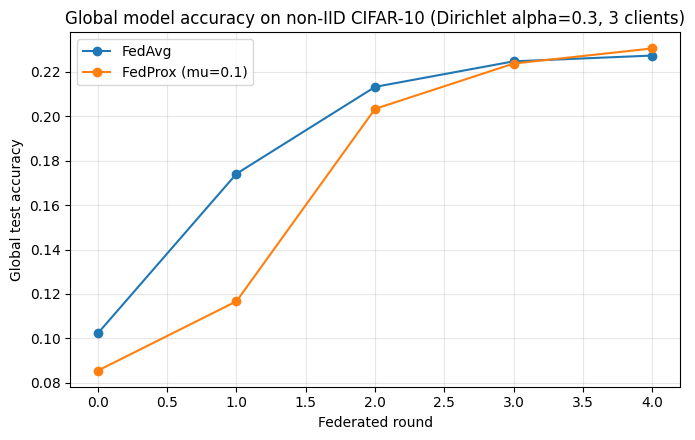

[fedavg] final global model checkpoint: /tmp/nvflare/fedavg_ws/server/simulate_job/app_server/FL_global_model.pt
[fedprox] final global model checkpoint: /tmp/nvflare/fedprox_ws/server/simulate_job/app_server/FL_global_model.pt


In [4]:
def load_curve(tag):
    rounds, accs = [], []
    with open(os.path.join(RESULTS_DIR, tag + ".csv")) as f:
        for line in f:
            r, a = line.strip().split(",")
            rounds.append(int(r)); accs.append(float(a))
    order = np.argsort(rounds)
    return np.array(rounds)[order], np.array(accs)[order]

plt.figure(figsize=(7, 4.5))
for tag, label in [("fedavg", "FedAvg"), ("fedprox", "FedProx (mu=0.1)")]:
    r, a = load_curve(tag)
    plt.plot(r, a, marker="o", label=label)
plt.title(f"Global model accuracy on non-IID CIFAR-10 (Dirichlet alpha={ALPHA}, {NUM_SITES} clients)")
plt.xlabel("Federated round"); plt.ylabel("Global test accuracy")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

for tag in ["fedavg", "fedprox"]:
    try:
        ckpt = glob.glob(f"/tmp/nvflare/{tag}_ws/**/FL_global_model.pt", recursive=True)[0]
        obj = torch.load(ckpt, map_location="cpu", weights_only=False)
        state = obj.get("model", obj) if isinstance(obj, dict) else obj
        print(f"[{tag}] final global model checkpoint: {ckpt}")
    except Exception as e:
        print(f"[{tag}] could not locate final checkpoint ({e})")